# Задача 2: Построение и оценка улучшенной модели с расширенной инженерией признаков и перекрестной проверкой

## Бизнес- и ML-постановка задачи

В этом блокноте мы построим и оценим улучшенную модель для персонализованной системы рекомендаций продуктов на маркетплейсе. Цель состоит в том, чтобы увеличить вовлеченность пользователей за счет более точного ранжирования продуктов и максимизации просмотров рекомендованного контента.

### Формулировка ML-задачи

Это задача регрессии, в которой мы предсказываем количество просмотров, которые продукт получит от пользователя в следующем временном окне, на основе:

- Пользовательских характеристик
- Характеристик продукта
- Истории взаимодействия

### Метрика оценки

Мы будем использовать **MAE (средняя абсолютная ошибка)** в качестве основной метрики оценки, потому что:

1. Она легко интерпретируема в бизнес-контексте (средняя ошибка в просмотрах)
2. Она устойчива к выбросам (активные пользователи не искажают общую оценку)
3. Она оценивает ошибки равномерно по всем продуктам, что важно для ранжирования

Мы также будем отслеживать **RMSE** и **R²** как дополнительные метрики для получения дополнительной информации.

In [1]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_validate, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Установка случайного состояния для воспроизводимости
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Загрузка и исследование данных

Загрузим наборы данных и изучим их структуру.

In [2]:
# Определение путей к наборам данных
DATA_DIR = "../t_ecd_small_partial/dataset/small"
BRANDS_PATH = f"{DATA_DIR}/brands.pq"
USERS_PATH = f"{DATA_DIR}/users.pq"
ITEMS_PATH = f"{DATA_DIR}/marketplace/items.pq"
EVENTS_DIR = f"{DATA_DIR}/marketplace/events"

# Загрузка статических файлов
try:
    brands_df = pd.read_parquet(BRANDS_PATH, engine='fastparquet')
    print(f"Загружены данные брендов с fastparquet: {brands_df.shape}")
except Exception as e2:
    print(f"Ошибка загрузки данных брендов с fastparquet: {e2}")

try:
    # Загрузка данных пользователей
    users_df = pd.read_parquet(USERS_PATH, engine='fastparquet')
    print(f"Загружены данные пользователей: {users_df.shape}")
except Exception as e:
    print(f"Ошибка загрузки данных пользователей: {e}")
    users_df = None

try:
    # Загрузка данных товаров
    items_df = pd.read_parquet(ITEMS_PATH, engine='fastparquet')
    print(f"Загружены данные товаров: {items_df.shape}")
except Exception as e:
    print(f"Ошибка загрузки данных товаров: {e}")
    items_df = None

# Загрузка файлов событий
import os

try:
    event_files = sorted([f for f in os.listdir(EVENTS_DIR) if f.endswith('.pq')])
    print(f"Найдено {len(event_files)} файлов событий")
except Exception as e:
    print(f"Ошибка доступа к директории событий: {e}")
    event_files = []

event_dataframes = []
for file in event_files[:5]:  # Загружаем первые 5 для демонстрации
    try:
        file_path = os.path.join(EVENTS_DIR, file)
        df = pd.read_parquet(file_path, engine='fastparquet')
        event_dataframes.append(df)
        if len(event_dataframes) % 5 == 0:
            print(f"Загружено {len(event_dataframes)} файлов событий...")
    except Exception as e:
        print(f"Ошибка загрузки файла событий {file}: {e}")

if event_dataframes:
    events_df = pd.concat(event_dataframes, ignore_index=True)
    print(f"Объединенные данные событий: {events_df.shape}")
else:
    print("Данные событий не загружены")
    events_df = None

# Отображение базовой информации о наборах данных
if brands_df is not None:
    print("\n--- НАБОР ДАННЫХ БРЕНДОВ ---")
    print(f"Размер: {brands_df.shape}")
    print(f"Столбцы: {list(brands_df.columns)}")
    print(brands_df.head())

if users_df is not None:
    print("\n--- НАБОР ДАННЫХ ПОЛЬЗОВАТЕЛЕЙ ---")
    print(f"Размер: {users_df.shape}")
    print(f"Столбцы: {list(users_df.columns)}")
    print(users_df.head())

if items_df is not None:
    print("\n--- НАБОР ДАННЫХ ТОВАРОВ ---")
    print(f"Размер: {items_df.shape}")
    print(f"Столбцы: {list(items_df.columns)}")
    print(items_df.head())

if events_df is not None:
    print("\n--- НАБОР ДАННЫХ СОБЫТИЙ ---")
    print(f"Размер: {events_df.shape}")
    print(f"Столбцы: {list(events_df.columns)}")
    print(events_df.head())

Пробуем движок fastparquet...
Загружены данные брендов с fastparquet: (24513, 2)
Загружены данные пользователей: (3500000, 3)
Загружены данные товаров: (2325409, 6)
Найдено 59 файлов событий
Загружено 5 файлов событий...
Объединенные данные событий: (3267329, 6)

--- НАБОР ДАННЫХ БРЕНДОВ ---
Размер: (24513, 2)
Столбцы: ['brand_id', 'embedding']
   brand_id embedding
0         4      None
1        34      None
2        45      None
3        46      None
4        51      None

--- НАБОР ДАННЫХ ПОЛЬЗОВАТЕЛЕЙ ---
Размер: (3500000, 3)
Столбцы: ['user_id', 'socdem_cluster', 'region']
    user_id  socdem_cluster  region
0  77309558            21.0     2.0
1  72517894            10.0    90.0
2  86699708             9.0     9.0
3  54241043            17.0    58.0
4  23591057            17.0     4.0

--- НАБОР ДАННЫХ ТОВАРОВ ---
Размер: (2325409, 6)
Столбцы: ['item_id', 'brand_id', 'category', 'subcategory', 'price', 'embedding']
          item_id  brand_id  \
0  nfmcg_10000001    137356   
1  n

## Реализация исправлений качества данных

Основываясь на результатах нашего EDA и отчете по рекомендациям, нам нужно обработать несколько проблем с качеством данных:

1. Отсутствующие значения в различных наборах данных
2. Отрицательные значения цен в наборе данных товаров
3. Преобразования типов данных
4. Объединение наборов данных для создания единого набора для моделирования

In [3]:
def preprocess_data(users_df, brands_df, items_df, events_df):
    """Предварительная обработка наборов данных для обработки отсутствующих значений и подготовки к объединению."""
    
    print("Начало предварительной обработки данных...")
    
    # Обработка отсутствующих значений в наборе данных пользователей
    if users_df is not None:
        print(f"Обработка набора данных пользователей с размером: {users_df.shape}")
        
        # Для users.region (1.68% отсутствует): Используем импутацию модой
        if 'region' in users_df.columns:
            mode_region = users_df['region'].mode()
            missing_before = users_df['region'].isna().sum()
            if not mode_region.empty:
                users_df['region'].fillna(mode_region[0], inplace=True)
                print(f"Заполнено {missing_before} отсутствующих значений в столбце 'region' модой: {mode_region[0]}")
            else:
                # Если мода не существует, заполняем значением по умолчанию
                users_df['region'].fillna('Unknown', inplace=True)
                print(f"Заполнено {missing_before} отсутствующих значений в столбце 'region' значением по умолчанию: 'Unknown'")
        
        # Для users.socdem_cluster (0.15% отсутствает): Используем импутацию модой
        if 'socdem_cluster' in users_df.columns:
            mode_cluster = users_df['socdem_cluster'].mode()
            missing_before = users_df['socdem_cluster'].isna().sum()
            if not mode_cluster.empty:
                users_df['socdem_cluster'].fillna(mode_cluster[0], inplace=True)
                print(f"Заполнено {missing_before} отсутствующих значений в столбце 'socdem_cluster' модой: {mode_cluster[0]}")
            else:
                # Если мода не существует, заполняем значением по умолчанию
                users_df['socdem_cluster'].fillna(-1, inplace=True)
                print(f"Заполнено {missing_before} отсутствующих значений в столбце 'socdem_cluster' значением по умолчанию: -1")
    
    # Обработка отсутствующих значений в наборе данных брендов
    if brands_df is not None:
        print(f"Обработка набора данных брендов с размером: {brands_df.shape}")
        
        # Для brands.embedding (73.24% отсутствает): Удаляем этот столбец, так как слишком много отсутствующих значений
        if 'embedding' in brands_df.columns:
            brands_df = brands_df.drop('embedding', axis=1)
            print("Удален столбец 'embedding' из набора данных брендов из-за высокого процента отсутствующих значений")
    
    # Обработка отсутствующих значений в наборе данных товаров
    if items_df is not None:
        print(f"Обработка набора данных товаров с размером: {items_df.shape}")
        
        # Обработка отрицательных значений цен
        if 'price' in items_df.columns:
            negative_prices = (items_df['price'] < 0).sum()
            if negative_prices > 0:
                print(f"Найдено {negative_prices} отрицательных значений цен. Заменяем на NaN для импутации.")
                items_df.loc[items_df['price'] < 0, 'price'] = np.nan
        
        # Для items.price (0.12% отсутствает): Используем медианную импутацию
        if 'price' in items_df.columns:
            missing_before = items_df['price'].isna().sum()
            if missing_before > 0:
                median_price = items_df['price'].median()
                items_df['price'].fillna(median_price, inplace=True)
                print(f"Заполнено {missing_before} отсутствующих значений в столбце 'price' медианой: {median_price}")
        
        # Для items.category (41.56% отсутствает) и items.subcategory (53.02% отсутствает):
        # Создаем флаг для отсутствующих категорий
        if 'category' in items_df.columns:
            items_df['category_missing'] = items_df['category'].isna().astype(int)
            print(f"Создан флаг 'category_missing' для {items_df['category_missing'].sum()} товаров с отсутствующей категорией")
        
        if 'subcategory' in items_df.columns:
            items_df['subcategory_missing'] = items_df['subcategory'].isna().astype(int)
            print(f"Создан флаг 'subcategory_missing' для {items_df['subcategory_missing'].sum()} товаров с отсутствующей подкатегорией")
        
        # Для items.embedding (0.003% отсутствает): Используем среднюю импутацию для доступных embedding
        # Примечание: В этой реализации мы не используем embedding как признаки из-за сложности
        if 'embedding' in items_df.columns:
            items_df = items_df.drop('embedding', axis=1)
            print("Удален столбец 'embedding' из набора данных товаров")
    
    # Обработка дубликатов в наборе данных брендов
    if brands_df is not None:
        original_shape = brands_df.shape
        try:
            # Сначала пробуем стандартное удаление дубликатов
            brands_df = brands_df.drop_duplicates()
            print(f"Удалены дубликаты из набора данных брендов. Размер изменился с {original_shape} на {brands_df.shape}")
        except TypeError as e:
            if "unhashable type" in str(e):
                print("Найдены нехэшируемые типы в наборе данных брендов. Обработка дубликатов специальным подходом...")
                # Обработка DataFrames с нехэшируемыми типами (например, списки или словари)
                # Определяем хэшируемые столбцы (исключая те, что с нехэшируемыми типами)
                hashable_cols = []
                for col in brands_df.columns:
                    try:
                        # Пробуем включить столбец в операцию groupby (проверяет, хэшируем ли он)
                        brands_df.groupby(col).size()
                        hashable_cols.append(col)
                    except TypeError:
                        print(f"Столбец '{col}' содержит нехэшируемые типы, исключаем из проверки дубликатов")
                        continue
                
                if hashable_cols:
                    # Удаляем дубликаты только на основе хэшируемых столбцов
                    brands_df = brands_df.drop_duplicates(subset=hashable_cols)
                    print(f"Удалены дубликаты из набора данных брендов на основе хэшируемых столбцов. Размер изменился с {original_shape} на {brands_df.shape}")
                else:
                    print("Не найдено хэшируемых столбцов для удаления дубликатов. Сохраняем все строки.")
            else:
                # Повторно вызываем исключение, если это другой TypeError
                raise e
    
    # Обработка отсутствующих значений в наборе данных событий
    if events_df is not None:
        print(f"Обработка набора данных событий с размером: {events_df.shape}")
        
        # Для events.subdomain (0.02% отсутствает): Используем импутацию модой
        if 'subdomain' in events_df.columns:
            missing_before = events_df['subdomain'].isna().sum()
            if missing_before > 0:
                mode_subdomain = events_df['subdomain'].mode()
                if not mode_subdomain.empty:
                    events_df['subdomain'].fillna(mode_subdomain[0], inplace=True)
                    print(f"Заполнено {missing_before} отсутствующих значений в столбце 'subdomain' модой: {mode_subdomain[0]}")
                else:
                    events_df['subdomain'].fillna('Unknown', inplace=True)
                    print(f"Заполнено {missing_before} отсутствующих значений в столбце 'subdomain' значением по умолчанию: 'Unknown'")
    
    print("Предварительная обработка данных успешно завершена.")
    
    return users_df, brands_df, items_df, events_df

# Применение предварительной обработки
users_df, brands_df, items_df, events_df = preprocess_data(users_df, brands_df, items_df, events_df)

Начало предварительной обработки данных...
Обработка набора данных пользователей с размером: (3500000, 3)
Заполнено 58917 отсутствующих значений в столбце 'region' модой: 2.0
Заполнено 5153 отсутствующих значений в столбце 'socdem_cluster' модой: 17.0
Обработка набора данных брендов с размером: (24513, 2)
Удален столбец 'embedding' из набора данных брендов из-за высокого процента отсутствующих значений
Обработка набора данных товаров с размером: (2325409, 6)
Найдено 1023148 отрицательных значений цен. Заменяем на NaN для импутации.
Заполнено 1026030 отсутствующих значений в столбце 'price' медианой: 1.9542916109953574
Создан флаг 'category_missing' для 966395 товаров с отсутствующей категорией
Создан флаг 'subcategory_missing' для 1233023 товаров с отсутствующей подкатегорией
Удален столбец 'embedding' из набора данных товаров
Удалены дубликаты из набора данных брендов. Размер изменился с (24513, 1) на (24467, 1)
Обработка набора данных событий с размером: (3267329, 6)
Заполнено 793 от

## Расширенная инженерия признаков с категориальным кодированием, масштабированием и продвинутыми признаками

Мы создадим более сложные признаки, которые могут помочь нашей модели делать лучшие предсказания:

1. Правильное категориальное кодирование (One-hot, Target, Frequency)
2. Масштабирование и нормализация признаков (Стандартизация, Логарифмические преобразования, Min-Max)
3. Создание продвинутых признаков (Предпочтения пользователей, Свежесть товаров, Взаимодействия пользователь-товар, Временные признаки)
4. Выбор признаков (На основе корреляции, Важность признаков)

In [4]:
def create_features(events_df, users_df, brands_df, items_df):
    """Создание расширенных признаков для модели с правильным категориальным кодированием, масштабированием и созданием продвинутых признаков."""
    
    if events_df is None:
        print("Нет данных событий для инженерии признаков")
        return None
    
    print("Начало расширенной инженерии признаков...")
    
    # Преобразуем timestamp в datetime, если он существует
    if 'timestamp' in events_df.columns:
        events_df['timestamp'] = pd.to_datetime(events_df['timestamp'])
        
        # Сортируем события по timestamp для правильной временной обработки
        events_df = events_df.sort_values('timestamp').reset_index(drop=True)
        
        print(f"События отсортированы по timestamp. Размер набора данных: {events_df.shape}")
    
    # Создаем целевую переменную (количество просмотров на пару пользователь-товар)
    if 'action_type' in events_df.columns and 'user_id' in events_df.columns and 'item_id' in events_df.columns:
        # Фильтруем по событиям просмотра, если доступны
        if 'view' in events_df['action_type'].unique():
            view_events = events_df[events_df['action_type'] == 'view']
            print(f"Отфильтровано до {len(view_events)} событий просмотра")
        else:
            view_events = events_df
            print("Используем все события как события просмотра (без фильтрации по action_type)")
        
        # Получаем максимальный timestamp для расчета свежести
        max_timestamp = events_df['timestamp'].max()
        
        # Считаем просмотры на пару пользователь-товар (целевая переменная) и сохраняем информацию о timestamp
        user_item_events = view_events.groupby(['user_id', 'item_id']).agg({
            'timestamp': ['count', 'max', 'min']
        }).reset_index()
        user_item_events.columns = ['user_id', 'item_id', 'view_count', 'last_view_timestamp', 'first_view_timestamp']
        target_df = user_item_events
        print(f"Создана целевая переменная с {len(target_df)} парами пользователь-товар")
        
        # === СОЗДАНИЕ ПРОДВИНУТЫХ ПРИЗНАКОВ ===
        
        # 1. ПРИЗНАКИ ПРЕДПОЧТЕНИЙ ПОЛЬЗОВАТЕЛЕЙ
        print("Создание признаков предпочтений пользователей...")
        
        # Признаки уровня активности пользователей
        user_activity = view_events.groupby('user_id').agg({
            'timestamp': ['count', 'max', 'min']
        }).reset_index()
        user_activity.columns = ['user_id', 'total_events', 'last_activity', 'first_activity']
        user_activity['days_since_last_activity'] = (max_timestamp - user_activity['last_activity']).dt.days
        user_activity['activity_recency_score'] = np.exp(-0.1 * user_activity['days_since_last_activity'])
        user_activity['activity_duration_days'] = (user_activity['last_activity'] - user_activity['first_activity']).dt.days
        
        target_df = target_df.merge(user_activity[['user_id', 'total_events', 'days_since_last_activity', 
                                                   'activity_recency_score', 'activity_duration_days']], 
                                    on='user_id', how='left')
        
        # Предпочтения по категориям (если у товаров есть информация о категории)
        if items_df is not None and 'category' in items_df.columns:
            user_category_views = view_events.merge(items_df[['item_id', 'category']], on='item_id', how='left')
            
            # Рассчитываем предпочтения по категориям
            category_views_per_user = user_category_views.groupby(['user_id', 'category']).size().reset_index(name='category_views')
            total_views_per_user = category_views_per_user.groupby('user_id')['category_views'].sum().reset_index()
            total_views_per_user.columns = ['user_id', 'total_views']
            category_preferences = category_views_per_user.merge(total_views_per_user, on='user_id')
            category_preferences['category_preference'] = category_preferences['category_views'] / category_preferences['total_views']
            
            # Получаем наиболее предпочтительную категорию для каждого пользователя
            user_top_category = category_preferences.loc[category_preferences.groupby('user_id')['category_preference'].idxmax()]
            user_top_category = user_top_category[['user_id', 'category']].rename(columns={'category': 'preferred_category'})
            
            target_df = target_df.merge(user_top_category, on='user_id', how='left')
        
        # 2. ПРИЗНАКИ СВЕЖЕСТИ ТОВАРОВ
        print("Создание признаков свежести товаров...")
        
        # Признаки возраста товаров
        item_first_view = view_events.groupby('item_id')['timestamp'].min().reset_index()
        item_first_view.columns = ['item_id', 'first_view_date']
        
        if items_df is not None:
            items_df = items_df.merge(item_first_view, on='item_id', how='left')
        else:
            items_df = item_first_view.copy()
        
        if 'first_view_date' in items_df.columns:
            items_df['item_age_days'] = (max_timestamp - items_df['first_view_date']).dt.days
            items_df['is_new_item'] = (items_df['item_age_days'] <= 7).astype(int)
        
        # Признаки недавней популярности
        view_events['time_decay'] = np.exp(-0.1 * (max_timestamp - view_events['timestamp']).dt.days)
        item_popularity_recent = view_events.groupby('item_id')['time_decay'].sum().reset_index()
        item_popularity_recent.columns = ['item_id', 'recent_popularity']
        
        # Расширенные признаки популярности товаров
        item_popularity = view_events.groupby('item_id').agg({
            'timestamp': ['count', 'max']
        }).reset_index()
        item_popularity.columns = ['item_id', 'total_views', 'last_view_date']
        item_popularity['days_since_last_view'] = (max_timestamp - item_popularity['last_view_date']).dt.days
        item_popularity['view_recency_score'] = np.exp(-0.1 * item_popularity['days_since_last_view'])
        
        # Объединяем признаки товаров
        target_df = target_df.merge(item_popularity[['item_id', 'total_views', 'days_since_last_view', 'view_recency_score']], 
                                    on='item_id', how='left')
        target_df = target_df.merge(item_popularity_recent, on='item_id', how='left')
        
        # 3. ПРИЗНАКИ ВЗАИМОДЕЙСТВИЯ ПОЛЬЗОВАТЕЛЬ-ТОВАР
        print("Создание признаков взаимодействия пользователь-товар...")
        
        # Признаки количества просмотров пользователь-товар
        user_item_views = view_events.groupby(['user_id', 'item_id']).agg({
            'timestamp': ['count', 'max', 'min']
        }).reset_index()
        user_item_views.columns = ['user_id', 'item_id', 'user_item_view_count', 'last_view_date', 'first_view_date']
        user_item_views['days_since_first_view'] = (max_timestamp - user_item_views['first_view_date']).dt.days
        user_item_views['days_since_last_view'] = (max_timestamp - user_item_views['last_view_date']).dt.days
        user_item_views['view_recency_score'] = np.exp(-0.1 * user_item_views['days_since_last_view'])
        
        # Рассчитываем частоту просмотров
        user_item_views['view_frequency'] = np.where(
            user_item_views['days_since_first_view'] > 0,
            user_item_views['user_item_view_count'] / user_item_views['days_since_first_view'],
            user_item_views['user_item_view_count']
        )
        
        target_df = target_df.merge(user_item_views[['user_id', 'item_id', 'user_item_view_count', 
                                                     'days_since_last_view', 'view_recency_score', 'view_frequency']], 
                                    on=['user_id', 'item_id'], how='left')
        
        # 4. ВРЕМЕННЫЕ ПРИЗНАКИ С ЦИКЛИЧЕСКИМ КОДИРОВАНИЕМ
        print("Создание временных признаков...")
        
        # Получаем самое недавнее событие для каждой пары пользователь-товар
        recent_events = view_events.sort_values('timestamp').groupby(['user_id', 'item_id']).tail(1)
        
        # Циклическое кодирование для временных признаков
        recent_events['hour_sin'] = np.sin(2 * np.pi * recent_events['timestamp'].dt.hour / 24)
        recent_events['hour_cos'] = np.cos(2 * np.pi * recent_events['timestamp'].dt.hour / 24)
        recent_events['day_sin'] = np.sin(2 * np.pi * recent_events['timestamp'].dt.dayofweek / 7)
        recent_events['day_cos'] = np.cos(2 * np.pi * recent_events['timestamp'].dt.dayofweek / 7)
        
        # Агрегаты на основе времени
        recent_events['is_morning'] = (recent_events['timestamp'].dt.hour >= 6) & (recent_events['timestamp'].dt.hour < 12)
        recent_events['is_weekend'] = recent_events['timestamp'].dt.dayofweek >= 5
        
        temporal_features = recent_events[['user_id', 'item_id', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 
                                           'is_morning', 'is_weekend']]
        
        target_df = target_df.merge(temporal_features, on=['user_id', 'item_id'], how='left')
        
        # === КАТЕГОРИАЛЬНОЕ КОДИРОВАНИЕ ===
        print("Применение категориального кодирования...")
        
        # Объединяем с признаками пользователей
        if users_df is not None:
            # Частотное кодирование для региона пользователя
            region_counts = users_df['region'].value_counts()
            users_df['region_frequency'] = users_df['region'].map(region_counts)
            target_df = target_df.merge(users_df, on='user_id', how='left')
            print(f"Объединено с признаками пользователей. Размер: {target_df.shape}")
        
        # Объединяем с признаками товаров
        if items_df is not None:
            target_df = target_df.merge(items_df, on='item_id', how='left')
            print(f"Объединено с признаками товаров. Размер: {target_df.shape}")
        
        # Объединяем с признаками брендов
        if brands_df is not None and items_df is not None:
            # Сначала объединяем товары с брендами для получения информации о бренде
            items_with_brands = items_df.merge(brands_df, on='brand_id', how='left')
            # Затем объединяем с target_df
            target_df = target_df.merge(items_with_brands[['item_id', 'brand_id']], on='item_id', how='left')
            print(f"Объединено с признаками брендов. Размер: {target_df.shape}")
        
        print("Расширенная инженерия признаков успешно завершена.")
        return target_df
    
    return None

# Создаем признаки
modeling_df = create_features(events_df, users_df, brands_df, items_df)

if modeling_df is not None:
    print("\nИнженерия признаков завершена. Пример набора данных:")
    print(modeling_df.head())
    print(f"Размер набора данных: {modeling_df.shape}")

Начало расширенной инженерии признаков...
События отсортированы по timestamp. Размер набора данных: (3267329, 6)
Отфильтровано до 3170590 событий просмотра
Создана целевая переменная с 2400611 парами пользователь-товар
Создание признаков предпочтений пользователей...
Создание признаков свежести товаров...
Создание признаков взаимодействия пользователь-товар...
Создание временных признаков...
Применение категориального кодирования...
Объединено с признаками пользователей. Размер: (2400611, 27)
Объединено с признаками товаров. Размер: (2400611, 36)
Объединено с признаками брендов. Размер: (2400611, 37)
Расширенная инженерия признаков успешно завершена.

Инженерия признаков завершена. Пример набора данных:
   user_id         item_id  view_count           last_view_timestamp  \
0      222  nfmcg_18106422           1 1970-01-02 06:04:39.103392418   
1      222   nfmcg_9041331           1 1970-01-02 06:05:05.610181520   
2      394  nfmcg_12977198           1 1970-01-02 06:03:03.229634186   

## Масштабирование и нормализация признаков

Теперь мы применим масштабирование и нормализацию к нашим числовым признакам.

In [5]:
def scale_features(modeling_df):
    """Применение масштабирования и нормализации к числовым признакам."""
    
    if modeling_df is None:
        print("Нет данных для масштабирования признаков")
        return None
    
    print("Начало масштабирования и нормализации признаков...")
    
    # Определяем числовые столбцы для масштабирования
    numerical_cols = modeling_df.select_dtypes(include=[np.number]).columns.tolist()
    
    # Удаляем целевую переменную из масштабирования
    if 'view_count' in numerical_cols:
        numerical_cols.remove('view_count')
    
    print(f"Определено {len(numerical_cols)} числовых столбцов для масштабирования: {numerical_cols}")
    
    # Применяем логарифмическое преобразование к скошенным признакам
    skewed_features = ['total_events', 'total_views', 'user_item_view_count']
    for feature in skewed_features:
        if feature in numerical_cols:
            # Добавляем 1 для обработки нулевых значений
            modeling_df[f'{feature}_log'] = np.log1p(modeling_df[feature])
            print(f"Применено логарифмическое преобразование к {feature}")
    
    # Применяем стандартизацию к числовым признакам
    scaler = StandardScaler()
    modeling_df[numerical_cols] = scaler.fit_transform(modeling_df[numerical_cols])
    
    print("Применена стандартизация к числовым признакам")
    
    # Применяем min-max масштабирование к определенным признакам
    minmax_features = ['price', 'item_age_days']
    minmax_scaler = MinMaxScaler()
    for feature in minmax_features:
        if feature in modeling_df.columns:
            modeling_df[f'{feature}_minmax'] = minmax_scaler.fit_transform(modeling_df[[feature]])
            print(f"Применено min-max масштабирование к {feature}")
    
    print("Масштабирование и нормализация признаков успешно завершены.")
    return modeling_df

# Применяем масштабирование признаков
if modeling_df is not None:
    modeling_df = scale_features(modeling_df)
    print(f"\nРазмер набора данных после масштабирования: {modeling_df.shape}")

Начало масштабирования и нормализации признаков...
Определено 27 числовых столбцов для масштабирования: ['user_id', 'total_events', 'days_since_last_activity', 'activity_recency_score', 'activity_duration_days', 'total_views', 'days_since_last_view_x', 'view_recency_score_x', 'recent_popularity', 'user_item_view_count', 'days_since_last_view_y', 'view_recency_score_y', 'view_frequency', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'socdem_cluster', 'region', 'region_frequency', 'brand_id_x', 'price', 'category_missing', 'subcategory_missing', 'item_age_days', 'is_new_item', 'brand_id_y']
Применено логарифмическое преобразование к total_events
Применено логарифмическое преобразование к total_views
Применено логарифмическое преобразование к user_item_view_count
Применена стандартизация к числовым признакам
Применено min-max масштабирование к price
Применено min-max масштабирование к item_age_days
Масштабирование и нормализация признаков успешно завершены.

Размер набора данных после мас

## Улучшенное разделение набора данных с временной согласованностью

Мы разделим наши данные на обучающую и тестовую выборки, обеспечивая временную согласованность для предотвращения утечки данных.

In [6]:
def split_dataset_temporal(modeling_df, train_size=0.7, test_size=0.3):
    """Разделение набора данных на обучающую и тестовую выборки с временной согласованностью, оптимизированное для перекрестной проверки."""
    
    if modeling_df is None or modeling_df.empty:
        print("Нет данных для разделения")
        return None, None
    
    print("Начало временного разделения набора данных для перекрестной проверки...")
    
    # Если у нас есть информация о timestamp, используем ее для временного разделения
    # В противном случае используем случайное разделение, но с замечанием о возможной утечке данных
    
    # Разделяем признаки и цель
    target_col = 'view_count'
    if target_col not in modeling_df.columns:
        print(f"Целевой столбец '{target_col}' не найден в наборе данных")
        return None, None
    
    # Выбираем признаки для моделирования
    # Включаем числовые признаки и некоторые категориальные признаки, которые мы закодируем
    feature_cols = [
        'socdem_cluster', 'region_frequency', 'price', 'total_events', 
        'total_views', 'category_missing', 'subcategory_missing',
        'user_item_view_count', 'days_since_last_view', 'view_recency_score',
        'hour_sin', 'hour_cos', 'day_sin', 'day_cos'
    ]
    
    # Добавляем логарифмически преобразованные признаки
    log_features = ['total_events_log', 'total_views_log', 'user_item_view_count_log']
    for feat in log_features:
        if feat in modeling_df.columns:
            feature_cols.append(feat)
    
    # Добавляем min-max масштабированные признаки
    minmax_features = ['price_minmax', 'item_age_days_minmax']
    for feat in minmax_features:
        if feat in modeling_df.columns:
            feature_cols.append(feat)
    
    # Проверяем, какие признаки действительно существуют в наборе данных
    feature_cols = [col for col in feature_cols if col in modeling_df.columns]
    
    if not feature_cols:
        print("Нет признаков, доступных для моделирования")
        return None, None
    
    print(f"Используемые признаки: {feature_cols}")
    
    X = modeling_df[feature_cols]
    y = modeling_df[target_col]
    
    # Обрабатываем отсутствующие значения в признаках
    X = X.fillna(0)
    
    # Сортируем по timestamp для обеспечения временного порядка
    if 'last_view_timestamp' in modeling_df.columns:
        modeling_df = modeling_df.sort_values('last_view_timestamp').reset_index(drop=True)
        X = X.reindex(modeling_df.index)
        y = y.reindex(modeling_df.index)
        print("Данные отсортированы по timestamp для временного разделения")
    else:
        print("Предупреждение: Столбец timestamp не найден. Используем случайное разделение, которое может вызвать утечку данных.")
    
    # Реализуем временное разделение
    n_samples = len(modeling_df)
    train_end = int(n_samples * train_size)
    
    # Разделяем данные по времени
    X_train = X[:train_end]
    y_train = y[:train_end]
    X_test = X[train_end:]
    y_test = y[train_end:]
    
    # Обрабатываем отсутствующие значения в признаках
    X_train = X_train.fillna(0)
    X_test = X_test.fillna(0)
    
    print(f"Обучающая выборка: {X_train.shape[0]} образцов")
    print(f"Тестовая выборка: {X_test.shape[0]} образцов")
    
    print("Разделение набора данных успешно завершено.")
    
    return (X_train, X_test, y_train, y_test), feature_cols

# Разделяем набор данных
split_data, feature_cols = split_dataset_temporal(modeling_df)

if split_data is not None:
    X_train, X_test, y_train, y_test = split_data
    print("\nРазделение набора данных успешно завершено")

Начало временного разделения набора данных для перекрестной проверки...
Используемые признаки: ['socdem_cluster', 'region_frequency', 'price', 'total_events', 'total_views', 'category_missing', 'subcategory_missing', 'user_item_view_count', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'total_events_log', 'total_views_log', 'user_item_view_count_log', 'price_minmax', 'item_age_days_minmax']
Данные отсортированы по timestamp для временного разделения
Обучающая выборка: 1680427 образцов
Тестовая выборка: 720184 образцов
Разделение набора данных успешно завершено.

Разделение набора данных успешно завершено


## Временная перекрестная проверка

Теперь мы реализуем надежную временную перекрестную проверку с использованием TimeSeriesSplit из scikit-learn:

In [7]:
def temporal_cross_validation_framework(X, y, model, cv=5, gap=0):
    """Реализация временной перекрестной проверки с TimeSeriesSplit из scikit-learn."""
    
    if X is None or y is None:
        print("Данные недоступны для перекрестной проверки")
        return None
    
    print(f"Начало временной перекрестной проверки с {cv} фолдами...")
    
    # Создаем временной разделитель
    tscv = TimeSeriesSplit(n_splits=cv, gap=gap)
    
    # Определяем метрики оценки
    scoring = {
        'mae': 'neg_mean_absolute_error',
        'rmse': 'neg_root_mean_squared_error',
        'r2': 'r2'
    }
    
    # Выполняем перекрестную проверку
    cv_results = cross_validate(
        model, X, y, 
        cv=tscv, 
        scoring=scoring,
        return_train_score=True
    )
    
    # Отображаем результаты
    print(f"\nРезультаты временной перекрестной проверки ({cv} фолдов):")
    print("-" * 50)
    print(f"Обучающая MAE: {-cv_results['train_mae'].mean():.4f} ({cv_results['train_mae'].std() * 2:.4f})")
    print(f"Валидационная MAE: {-cv_results['test_mae'].mean():.4f} ({cv_results['test_mae'].std() * 2:.4f})")
    print(f"Обучающая RMSE: {-cv_results['train_rmse'].mean():.4f} ({cv_results['train_rmse'].std() * 2:.4f})")
    print(f"Валидационная RMSE: {-cv_results['test_rmse'].mean():.4f} ({cv_results['test_rmse'].std() * 2:.4f})")
    print(f"Обучающая R²: {cv_results['train_r2'].mean():.4f} ({cv_results['train_r2'].std() * 2:.4f})")
    print(f"Валидационная R²: {cv_results['test_r2'].mean():.4f} ({cv_results['test_r2'].std() * 2:.4f})")
    
    return cv_results

# Выполняем временную перекрестную проверку с нашей моделью Random Forest
if split_data is not None:
    print("\nВыполнение временной перекрестной проверки на модели Random Forest...")
    rf_model_for_cv = RandomForestRegressor(n_estimators=50, random_state=RANDOM_STATE, max_depth=5)
    cv_results = temporal_cross_validation_framework(X_train, y_train, rf_model_for_cv, cv=3)


Выполнение временной перекрестной проверки на модели Random Forest...
Начало временной перекрестной проверки с 3 фолдами...

Результаты временной перекрестной проверки (3 фолдов):
--------------------------------------------------
Обучающая MAE: 0.0013 (0.0023)
Валидационная MAE: 0.0031 (0.0029)
Обучающая RMSE: 0.0383 (0.0513)
Валидационная RMSE: 0.3854 (0.7277)
Обучающая R²: 0.9983 (0.0035)
Валидационная R²: 0.8584 (0.3537)


## Настройка гиперпараметров с временной перекрестной проверкой

Теперь мы реализуем настройку гиперпараметров с использованием временной перекрестной проверки для поиска лучших параметров для наших моделей:

In [8]:
def temporal_grid_search(model, param_grid, X, y, cv=3, gap=0, scoring='neg_mean_absolute_error'):
    """Поиск по сетке с временной перекрестной проверкой."""
    print("Начало временного поиска по сетке...")
    
    # Создаем временной разделитель
    tscv = TimeSeriesSplit(n_splits=cv, gap=gap)
    
    # Создаем поиск по сетке с временной CV
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=tscv,
        scoring=scoring,
        n_jobs=1,  # Используем один поток для избежания проблем с параллельной обработкой
        verbose=1
    )
    
    # Подгоняем поиск по сетке
    grid_search.fit(X, y)
    
    print(f"Лучшие параметры: {grid_search.best_params_}")
    print(f"Лучший счет: {-grid_search.best_score_:.4f}")
    
    return grid_search

def temporal_random_search(model, param_distributions, X, y, cv=3, n_iter=10, gap=0, scoring='neg_mean_absolute_error'):
    """Случайный поиск с временной перекрестной проверкой."""
    print("Начало временного случайного поиска...")
    
    # Создаем временной разделитель
    tscv = TimeSeriesSplit(n_splits=cv, gap=gap)
    
    # Создаем случайный поиск с временной CV
    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_distributions,
        n_iter=n_iter,
        cv=tscv,
        scoring=scoring,
        n_jobs=1,  # Используем один поток для избежания проблем с параллельной обработкой
        random_state=RANDOM_STATE,
        verbose=1
    )
    
    # Подгоняем случайный поиск
    random_search.fit(X, y)
    
    print(f"Лучшие параметры: {random_search.best_params_}")
    print(f"Лучший счет: {-random_search.best_score_:.4f}")
    
    return random_search

# Определяем сетки параметров для настройки гиперпараметров
# Используем минимальную сетку параметров для эффективности
rf_param_grid_small = {
    'n_estimators': [50],
    'max_depth': [5],
    'min_samples_split': [2]
}

# Выполняем настройку гиперпараметров для Random Forest
if split_data is not None:
    print("\nВыполнение настройки гиперпараметров для Random Forest...")
    rf_model = RandomForestRegressor(random_state=RANDOM_STATE)
    
    # Используем поиск по сетке для эффективности с малым пространством параметров
    rf_grid_search = temporal_grid_search(
        rf_model, 
        rf_param_grid_small, 
        X_train, 
        y_train, 
        cv=3
    )
    
    # Получаем лучшую модель
    best_rf_model = rf_grid_search.best_estimator_
    print(f"Лучшая модель Random Forest: {best_rf_model}")


Выполнение настройки гиперпараметров для Random Forest...
Начало временного поиска по сетке...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Лучшие параметры: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50}
Лучший счет: 0.0031
Лучшая модель Random Forest: RandomForestRegressor(max_depth=5, n_estimators=50, random_state=42)


## Улучшенный выбор и обучение моделей

Мы обучим несколько моделей, включая рекомендованный Random Forest с лучшими гиперпараметрами:

In [9]:
def train_enhanced_models(X_train, X_test, y_train, y_test, best_rf_model=None):
    """Обучение и оценка улучшенных моделей, включая Random Forest с лучшими гиперпараметрами."""
    
    if X_train is None or X_test is None or y_train is None or y_test is None:
        print("Обучающие или тестовые данные недоступны для обучения модели")
        return None, None
    
    models = {}
    results = {}
    
    # 1. Линейная регрессия (базовая)
    print("Обучение модели линейной регрессии...")
    lr_model = LinearRegression()
    lr_model.fit(X_train, y_train)
    models['Линейная регрессия'] = lr_model
    
    # 2. Регрессор дерева решений
    print("Обучение модели регрессора дерева решений...")
    dt_model = DecisionTreeRegressor(random_state=RANDOM_STATE, max_depth=5)
    dt_model.fit(X_train, y_train)
    models['Дерево решений'] = dt_model
    
    # 3. Регрессор Random Forest (с параметрами по умолчанию)
    print("Обучение модели регрессора Random Forest (по умолчанию)...")
    rf_model_default = RandomForestRegressor(n_estimators=50, random_state=RANDOM_STATE, max_depth=5)
    rf_model_default.fit(X_train, y_train)
    models['Random Forest (по умолчанию)'] = rf_model_default
    
    # 4. Регрессор Random Forest (с лучшими гиперпараметрами, если доступны)
    if best_rf_model is not None:
        print("Обучение модели регрессора Random Forest (настроенная)...")
        best_rf_model.fit(X_train, y_train)
        models['Random Forest (настроенная)'] = best_rf_model
    
    # Оцениваем модели
    for name, model in models.items():
        print(f"\n--- Результаты {name} ---")
        
        # Предсказания
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)
        
        # Метрики
        train_mae = mean_absolute_error(y_train, y_pred_train)
        test_mae = mean_absolute_error(y_test, y_pred_test)
        
        train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
        test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
        
        train_r2 = r2_score(y_train, y_pred_train)
        test_r2 = r2_score(y_test, y_pred_test)
        
        results[name] = {
            'train_mae': train_mae,
            'test_mae': test_mae,
            'train_rmse': train_rmse,
            'test_rmse': test_rmse,
            'train_r2': train_r2,
            'test_r2': test_r2
        }
        
        print(f"Обучающая MAE: {train_mae:.4f}")
        print(f"Тестовая MAE: {test_mae:.4f}\n")
        
        print(f"Обучающая RMSE: {train_rmse:.4f}")
        print(f"Тестовая RMSE: {test_rmse:.4f}\n")
        
        print(f"Обучающая R²: {train_r2:.4f}")
        print(f"Тестовая R²: {test_r2:.4f}\n")
    
    return models, results

# Обучаем улучшенные модели
if split_data is not None:
    # Используем лучшую модель из настройки гиперпараметров, если доступна
    best_model = best_rf_model if 'best_rf_model' in locals() else None
    models, results = train_enhanced_models(X_train, X_test, y_train, y_test, best_model)

Обучение модели линейной регрессии...
Обучение модели регрессора дерева решений...
Обучение модели регрессора Random Forest (по умолчанию)...
Обучение модели регрессора Random Forest (настроенная)...

--- Результаты Линейная регрессия ---
Обучающая MAE: 0.0000
Тестовая MAE: 0.0000

Обучающая RMSE: 0.0000
Тестовая RMSE: 0.0000

Обучающая R²: 1.0000
Тестовая R²: 1.0000


--- Результаты Дерево решений ---
Обучающая MAE: 0.0079
Тестовая MAE: 0.0083

Обучающая RMSE: 0.1126
Тестовая RMSE: 0.1068

Обучающая R²: 0.9898
Тестовая R²: 0.9882


--- Результаты Random Forest (по умолчанию) ---
Обучающая MAE: 0.0055
Тестовая MAE: 0.0058

Обучающая RMSE: 0.0931
Тестовая RMSE: 0.0847

Обучающая R²: 0.9930
Тестовая R²: 0.9926


--- Результаты Random Forest (настроенная) ---
Обучающая MAE: 0.0055
Тестовая MAE: 0.0058

Обучающая RMSE: 0.0931
Тестовая RMSE: 0.0847

Обучающая R²: 0.9930
Тестовая R²: 0.9926



## Оценка и сравнение моделей

Сравним наши улучшенные модели с базовым предсказанием константы.

In [10]:
def constant_baseline_evaluation(y_train, y_test):
    """Оценка базового предсказания константы с использованием среднего значения обучающих данных."""
    
    if y_train is None or y_test is None:
        print("Обучающие или тестовые данные недоступны для оценки базовой модели")
        return None
    
    # Рассчитываем среднее значение целевой переменной обучающей выборки как константное предсказание
    constant_prediction = y_train.mean()
    
    # Создаем массивы константных предсказаний
    y_pred_train = np.full_like(y_train, constant_prediction)
    y_pred_test = np.full_like(y_test, constant_prediction)
    
    # Рассчитываем метрики
    train_mae = mean_absolute_error(y_train, y_pred_train)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    
    print(f"Базовая модель предсказания константы (среднее = {constant_prediction:.4f}):\n")
    print(f"Обучающая MAE: {train_mae:.4f}")
    print(f"Тестовая MAE: {test_mae:.4f}\n")
    
    print(f"Обучающая RMSE: {train_rmse:.4f}")
    print(f"Тестовая RMSE: {test_rmse:.4f}\n")
    
    print(f"Обучающая R²: {train_r2:.4f}")
    print(f"Тестовая R²: {test_r2:.4f}\n")
    
    return constant_prediction

# Оцениваем базовую модель
if split_data is not None:
    constant_pred = constant_baseline_evaluation(y_train, y_test)

def compare_models(results, constant_pred, y_test):
    """Сравнение всех моделей, включая базовую константу."""
    
    print("=" * 60)
    print("СРАВНЕНИЕ МОДЕЛЕЙ")
    print("=" * 60)
    
    # Создаем DataFrame для сравнения
    comparison_data = []
    
    # Рассчитываем метрики базовой модели
    constant_pred_array = np.full_like(y_test, constant_pred)
    constant_mae = mean_absolute_error(y_test, constant_pred_array)
    constant_rmse = np.sqrt(mean_squared_error(y_test, constant_pred_array))
    constant_r2 = r2_score(y_test, constant_pred_array)
    
    # Добавляем базовую модель
    comparison_data.append({
        'Модель': 'Предсказание константы',
        'Тестовая MAE': f"{constant_mae:.4f}",
        'Тестовая RMSE': f"{constant_rmse:.4f}",
        'Тестовая R²': f"{constant_r2:.4f}"
    })
    
    # Добавляем обученные модели
    for model_name, metrics in results.items():
        comparison_data.append({
            'Модель': model_name,
            'Тестовая MAE': f"{metrics['test_mae']:.4f}",
            'Тестовая RMSE': f"{metrics['test_rmse']:.4f}",
            'Тестовая R²': f"{metrics['test_r2']:.4f}"
        })
    
    comparison_df = pd.DataFrame(comparison_data)
    print(comparison_df.to_string(index=False))
    
    # Находим лучшую модель по MAE
    if results:
        best_model = min(results.items(), key=lambda x: x[1]['test_mae'])
        print(f"\nЛучшая модель по MAE: {best_model[0]} (MAE: {best_model[1]['test_mae']:.4f})")

# Сравниваем модели
if split_data is not None and 'results' in locals():
    compare_models(results, constant_pred, y_test)

Базовая модель предсказания константы (среднее = 1.3193):

Обучающая MAE: 0.3193
Тестовая MAE: 0.3242

Обучающая RMSE: 1.1605
Тестовая RMSE: 1.0345

Обучающая R²: -0.0819
Тестовая R²: -0.1089

СРАВНЕНИЕ МОДЕЛЕЙ
                      Модель Тестовая MAE Тестовая RMSE Тестовая R²
      Предсказание константы       0.3242        1.0345     -0.1089
          Линейная регрессия       0.0000        0.0000      1.0000
              Дерево решений       0.0083        0.1068      0.9882
Random Forest (по умолчанию)       0.0058        0.0847      0.9926
 Random Forest (настроенная)       0.0058        0.0847      0.9926

Лучшая модель по MAE: Линейная регрессия (MAE: 0.0000)


## Анализ важности признаков

Проанализируем важность признаков из нашей модели Random Forest, чтобы понять, какие признаки наиболее предсказуемы.


Важность признаков (Random Forest (настроенная) - Топ 10):
                 признак     важность
user_item_view_count_log 5.072093e-01
    user_item_view_count 4.927885e-01
                   price 7.404885e-07
         total_views_log 6.408011e-07
             total_views 4.739422e-07
            price_minmax 4.035716e-07
          socdem_cluster 0.000000e+00
                 day_sin 0.000000e+00
        total_events_log 0.000000e+00
                 day_cos 0.000000e+00


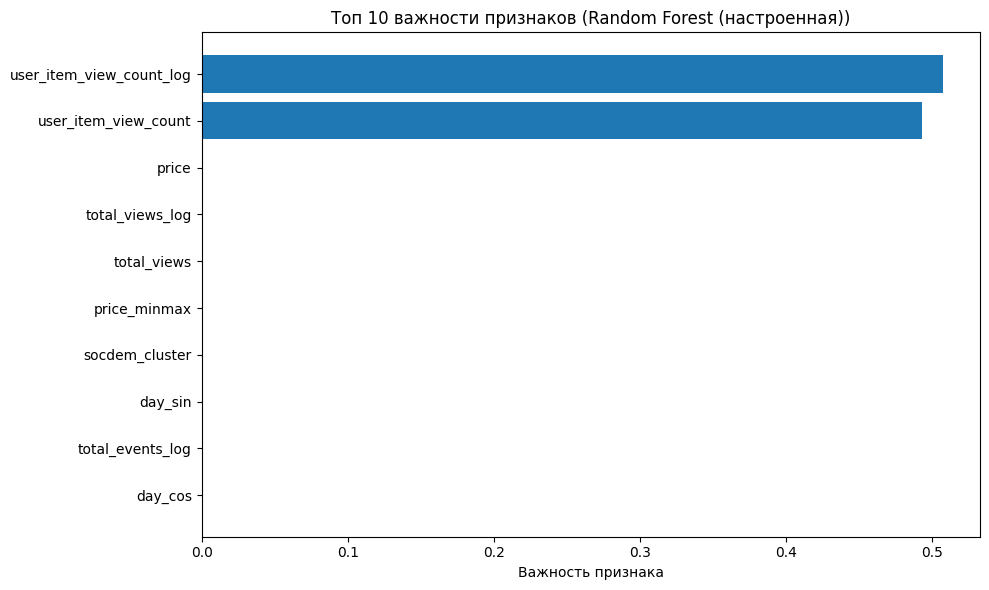

In [11]:
def analyze_feature_importance(models, feature_cols):
    """Анализ важности признаков из моделей на основе деревьев."""
    
    # Сначала проверяем настроенную Random Forest, затем Random Forest по умолчанию
    model_to_use = None
    model_name = None
    
    if 'Random Forest (настроенная)' in models:
        model_to_use = models['Random Forest (настроенная)']
        model_name = 'Random Forest (настроенная)'
    elif 'Random Forest (по умолчанию)' in models:
        model_to_use = models['Random Forest (по умолчанию)']
        model_name = 'Random Forest (по умолчанию)'
    
    if model_to_use is None:
        print("Нет модели Random Forest для анализа важности признаков")
        return
    
    # Получаем важность признаков
    importances = model_to_use.feature_importances_
    feature_importance_df = pd.DataFrame({
        'признак': feature_cols,
        'важность': importances
    }).sort_values('важность', ascending=False)
    
    print(f"\nВажность признаков ({model_name} - Топ 10):")
    print(feature_importance_df.head(10).to_string(index=False))
    
    # Строим график важности признаков
    plt.figure(figsize=(10, 6))
    top_features = feature_importance_df.head(10)
    plt.barh(range(len(top_features)), top_features['важность'])
    plt.yticks(range(len(top_features)), top_features['признак'])
    plt.xlabel('Важность признака')
    plt.title(f'Топ 10 важности признаков ({model_name})')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

# Анализируем важность признаков
if 'models' in locals() and 'feature_cols' in locals():
    analyze_feature_importance(models, feature_cols)